In [2]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import json

In [3]:
DISEASE = input("Disease: ")
OUTPUT_DIRECTORY = f"../output/{DISEASE}/"
NONE_OUTPUT_DIRECTORY  = f"../output/NONE/"
DATA_DIRECTORY = OUTPUT_DIRECTORY + "leiden_results"
DGIDB_DIRECTORY = f"../../Gen_Hypergraph/output/DGIDB_{DISEASE}/"

In [4]:
# load selected communities
with open(f"{DATA_DIRECTORY}/ddm_agg.pkl", "rb") as f:
    ddm_both = pickle.load(f)

In [5]:
# load npy arrays for NONE
ddm_msigdb = np.load(f"{NONE_OUTPUT_DIRECTORY}/diffusion_dist_matrices/ddm.npy")

# diffusion distance comparison

In [6]:
# average of each row
ddm_both_avg    = np.asarray(np.mean(ddm_both, axis=1)).ravel()
ddm_msigdb_avg = np.asarray(np.mean(ddm_msigdb, axis=1)).ravel()

In [7]:
# align the two arrays by length
print(len(ddm_both_avg), len(ddm_msigdb_avg))
min_length = min(len(ddm_both_avg), len(ddm_msigdb_avg))
print("Min length:", min_length)

21991 21981
Min length: 21981


In [8]:
# select the last min_length elements
ddm_both_avg_cropped = ddm_both_avg[-min_length:]

In [9]:
print(len(ddm_both_avg_cropped))
print(len(ddm_msigdb_avg))

21981
21981


In [10]:
# setting universal font sizes
font_size = 25
tick_font_size = 16
plt.rcParams.update({
    "font.size": font_size,          # base font size
    "axes.titlesize": font_size,
    "axes.labelsize": font_size,
    "xtick.labelsize": tick_font_size,
    "ytick.labelsize": tick_font_size,
    "legend.fontsize": font_size,
    "figure.titlesize": font_size,
    "legend.loc": 'best'
})


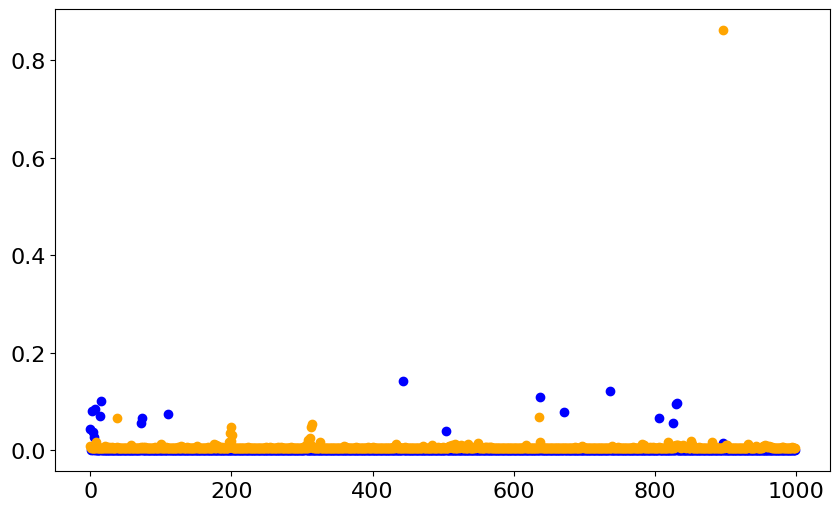

In [11]:
# sample 1000 points from each for better visualization
xaxis = np.arange(1000)
plt.figure(figsize=(10, 6))
plt.scatter(xaxis, ddm_both_avg_cropped[:1000], label='DDBC on Disease-specific Hypergraph', color='blue')
plt.scatter(xaxis, ddm_msigdb_avg[:1000], label='DDBC on MSigDB Hypergraph', color='orange')

In [12]:
import numpy as np
from scipy import stats

a = ddm_both_avg_cropped
b = ddm_msigdb_avg

# paired t-test
t_stat, p = stats.ttest_rel(a, b, nan_policy="omit")
print("paired t-test p-value:", p)

# nonparametric alternative
w_stat, p_w = stats.wilcoxon(a, b)
print("wilcoxon p-value:", p_w)


paired t-test p-value: 7.153599461960442e-248
wilcoxon p-value: 0.0


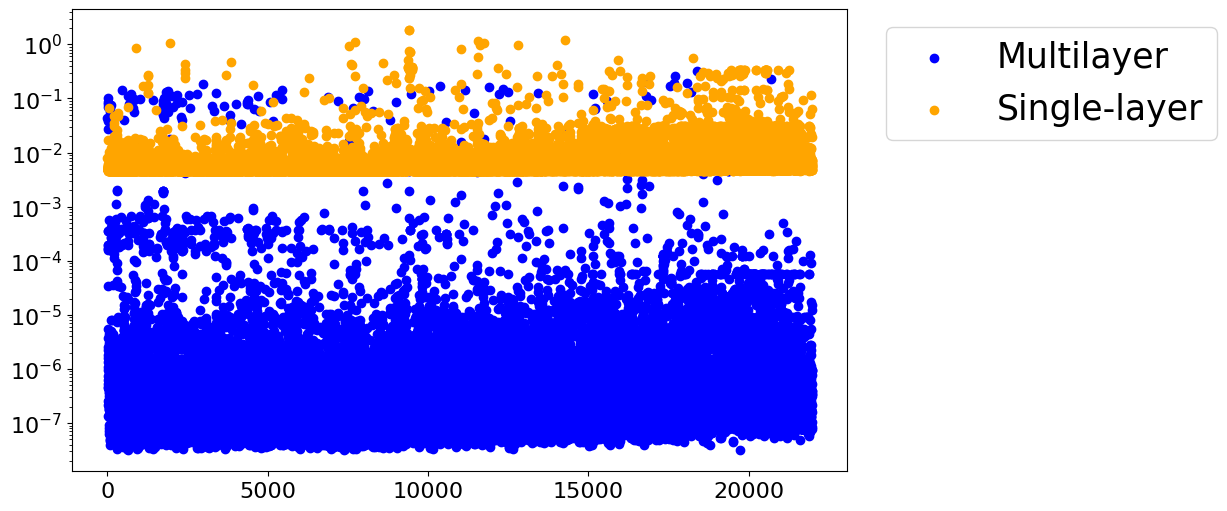

In [13]:
# scatterplot the two diffusion distance comparisons
xaxis = np.arange(min_length)
plt.figure(figsize=(10, 6))
plt.scatter(xaxis, ddm_both_avg_cropped, label='Multilayer', color='blue')
plt.scatter(xaxis, ddm_msigdb_avg, label='Single-layer', color='orange')
plt.yscale('log')
# legend placed outside of plot
plt.legend(bbox_to_anchor=(1.5, 1), loc='upper right')

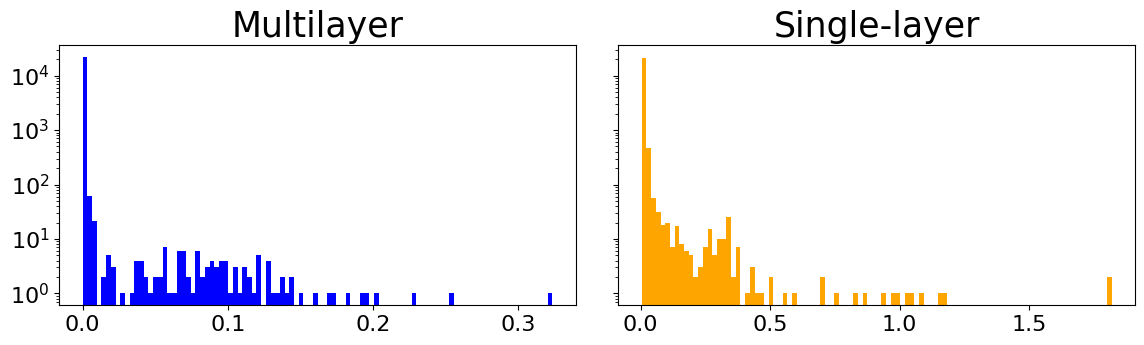

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax in axes:
    ax.set_yscale("log")

axes[0].hist(ddm_both_avg_cropped, bins=100, color='blue')
axes[0].set_title("Multilayer")

axes[1].hist(ddm_msigdb_avg, bins=100, color='orange')
axes[1].set_title("Single-layer")

plt.tight_layout()
plt.show()



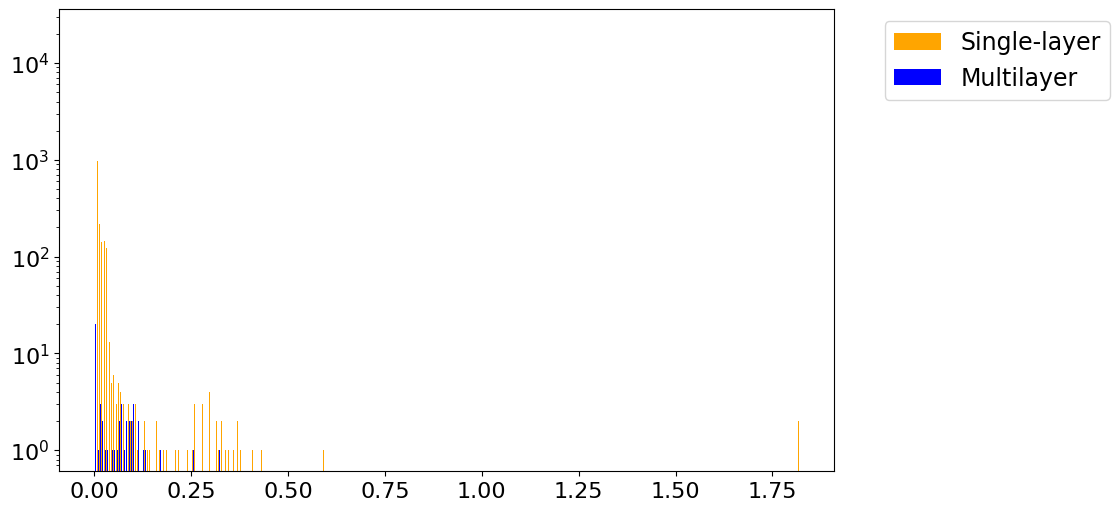

In [82]:
plt.figure(figsize=(10, 6))
plt.hist([ddm_msigdb_avg,ddm_both_avg_cropped], color=['orange', 'blue'], bins = 1000)
# plt.xlabel("Ratio of Average Diffusion Distances (Multilayer / Single-layer)", fontsize=17)
# plt.ylabel("Count", fontsize=17)
plt.yscale('log')
# legend placed outside of plot
plt.legend(['Single-layer', 'Multilayer'], bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=17)

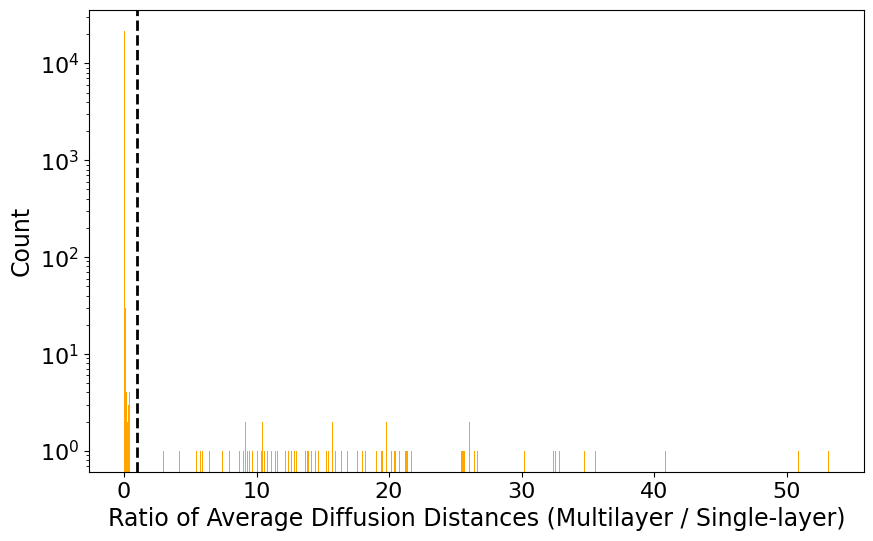

In [78]:
diff = ddm_both_avg_cropped / ddm_msigdb_avg

plt.figure(figsize=(10, 6))
plt.hist(diff, color='orange', bins = 1000)
plt.axvline(1, color="black", linestyle="--", linewidth=2, label="baseline = 1")
plt.xlabel("Ratio of Average Diffusion Distances (Multilayer / Single-layer)", fontsize=17)
plt.ylabel("Count", fontsize=17)
plt.yscale('log')
# legend placed outside of plot

In [45]:
diff

array([ -4.43052075,   0.96663244, -14.78704582, ...,   0.99937139,
         0.99987247,   0.99993006])